In [1]:
import numpy as np
from numpy.random import normal
import matplotlib.pyplot as plt

$$dx^i=A^i(x)d\tau+B^i_a(x)dW^a$$

$$i=1,...,var dim$$
$$a=1,..,noise dim$$

In [2]:
from qgravity import (
    EulerMaruyama,
    ItoSolver,
    OrnsteinUhlenbeck,
    QuadraticGravity,
    TrajectoryEnsemble,
    Scale_factor_calculator
)

In [23]:
TOTAL_TAU = 4
TAU_STEP = 10 ** -4
N_SAMPLES = 10
N_T_POINTS = 100

RNG = np.random.default_rng(42)


In [24]:
kappa = 100
epsilon = 0.1 
model = QuadraticGravity(sigma=epsilon,nu = kappa/3 * epsilon **2)


In [25]:
#model = QuadraticGravity(sigma=0.3,nu = 1)

In [26]:
solver = ItoSolver(model,EulerMaruyama(),TAU_STEP,TOTAL_TAU,RNG)

In [27]:
ens = TrajectoryEnsemble(solver,np.array([1,1,0]),(1,2))

In [28]:
trajs = ens.solve_many(N_SAMPLES)

In [29]:
calculator = Scale_factor_calculator(trajs,N_T_POINTS)

In [30]:
t, a, std = calculator.calculate_statistics()

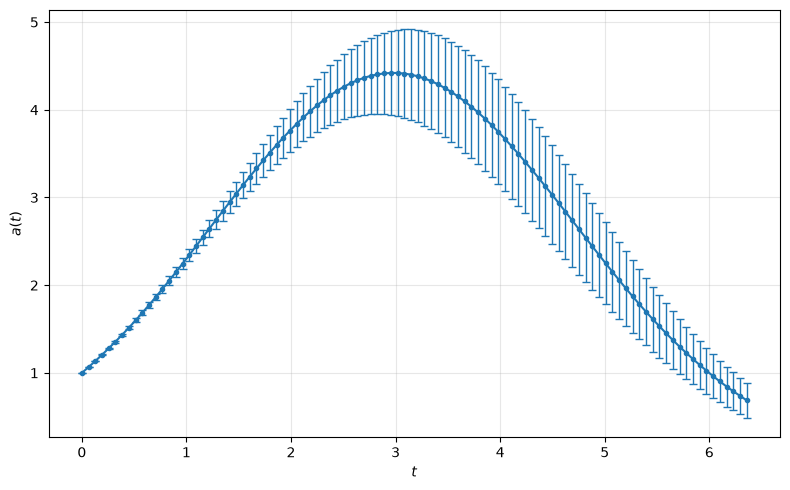

In [31]:
def plot_with_errors(x, y, y_err, xlabel="x", ylabel="y"):
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.errorbar(
        x, y,
        yerr=y_err,
        fmt="-o",
        markersize=3,
        capsize=3,
        elinewidth=1,
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    fig.tight_layout()

    return fig, ax


# Для результата Scale_factor_calculator:
fig, ax = plot_with_errors(
    t, a, std,
    xlabel=r"$t$",
    ylabel=r"$a(t)$",
)
plt.show()






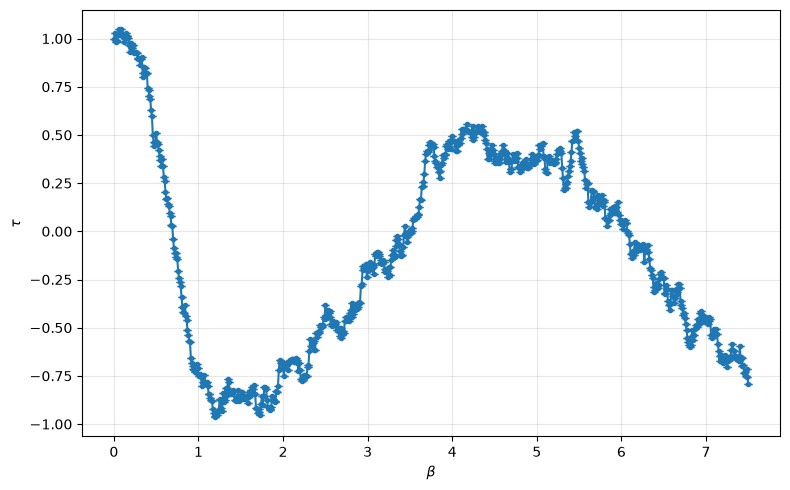

In [28]:
beta = solver.solve_one_process([1,1,0])[:,0]
#print(len(beta))
 
fig, ax = plot_with_errors(
    solver.tau_grid, beta , np.zeros_like(solver.tau_grid),
    xlabel=r"$\beta$",
    ylabel=r"$\tau$",
)
plt.show()
